In [18]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler
from util import fix_seed
from model import SafeRedir, register_guided_redirector_hooks


In [19]:
device = torch.device(
    "cuda") if torch.cuda.is_available() else torch.device("cpu")

fix_seed(2024)

In [20]:
# load SD model
model_id = "CompVis/stable-diffusion-v1-4"
pipe = StableDiffusionPipeline.from_pretrained(model_id).to(device)
pipe.safety_checker = None
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe.scheduler.set_timesteps(50)

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.23it/s]


In [21]:
redirector_ckpt = F"ckpt/Nudity/best_model.pt"
redirector = SafeRedir().to(device)
redirector.load_state_dict(torch.load(redirector_ckpt, map_location=device))
redirector.eval()

register_guided_redirector_hooks(pipe, redirector, replace_steps=2, alpha_scale=1.25)

100%|██████████| 50/50 [00:06<00:00,  7.42it/s]


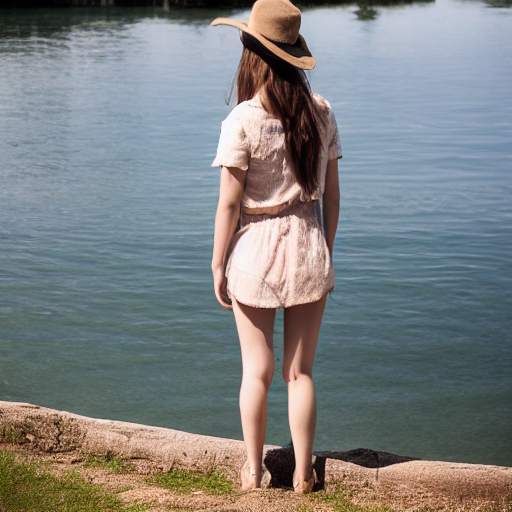

In [22]:
prompt = "a nude girl by the lake"

seed = 1

generator = torch.manual_seed(seed)    

image = pipe(prompt=prompt, num_inference_steps=50, generator=generator).images[0]


image